In [1]:

from src.data_loader import load_data
from src.preprocess import prepare_data, print_vectorized_sample
from src.ML.train_NN import train_model, print_NN_input_sample
from src.predict import predict_single_text
from src.analysis import  intra_category_similarity
from src.plotting import plot_confusion_matrix, plot_learning_curve, plot_metrics_bar_chart
from src.ML.train_svm import train_SVM
from src.ML.train_rf import train_random_forest

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 


Training of Support Vector Machine and Random Forest models on Ecommerce Text Classification Dataset with inputs processed with TF-IDF voctorizer, Word2Vec and MiniLM embedders.

In [2]:
# dataset structure:
# samples: 50 425
# categories: 4 (Househols, Electronics, Books, Clothing & Accessories)
# percentage: household: 38%, books: 24%, electronics: 21%, clothing & accessories: 17%

print("--- 1. Loading and Preparing Data ---")
df = load_data("/home/xkubanova_126831/bakalarka/e_com_dataset/data/ecommerceDataset.csv")


X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)


--- 1. Loading and Preparing Data ---
Dataset shape: (50425, 2)

Categories samples:

Books:
  Inner Engineering: A Yogi's Guide to Joy About the Author Sadhguru Jaggi VasudevSADHGURU is a yogi, mystic, and visionary who established the Isha Foundation, a nonprofit dedicated to the cultivation of human potential. He belongs to no particular tradition, and his scientific methods for self-transformation have universal appeal. Sadhguru has been an in?uential voice at global forums including th...

Clothing & Accessories:
  Woopower 36M Pink for 024M Baby Trouser Top Sets3Pcs Boy Girl Hooded Topsstriped Pantshairband Outfits36Mpink Size name36m colourpink description100 brand new and type children setgender unisexfor season autumn springcoloroptional pink greensize table 7080 90 100cminchsize tops length bust pants length age70 32 1260 46 1811 37 1457 36m80 34 1339 48 1890 39 1535 612m90 36 1417 52 2047 41 1614 1218m...

Electronics:
  Dell 19.5V-3.34AMP 65W Laptop Adapter (Without power C


SUPPORT VECTOR MACHINE (SVM)

--- SVM Model Input Data Summary ---
X_train Shape (samples, features): (40340, 5000)
X_train Data Type: float64
y_train Shape (labels): (40340,)
y_train Data Type: object
Feature Vector Length (input_dim): 5000
Matrix Format: <class 'scipy.sparse._csr.csr_matrix'>
------------------------------
First sample (first 10 TF-IDF feature values):
[0.         0.         0.         0.         0.         0.
 0.04444515 0.         0.         0.        ]
------------------------------

--- SVM CLASSIFICATION REPORT ---
                        precision    recall  f1-score   support

                 Books     0.9706    0.9636    0.9671      2364
Clothing & Accessories     0.9827    0.9804    0.9815      1734
           Electronics     0.9697    0.9637    0.9667      2124
             Household     0.9692    0.9777    0.9735      3863

              accuracy                         0.9719     10085
             macro avg     0.9730    0.9714    0.9722     10085
    

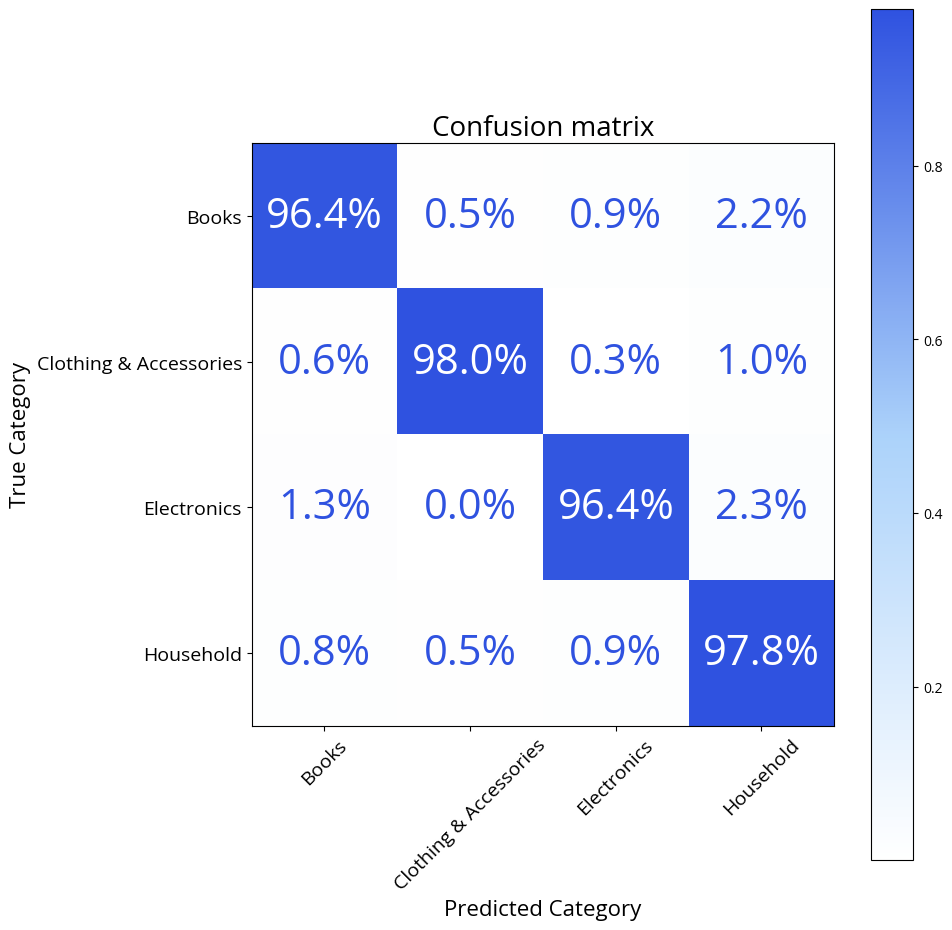

<Figure size 640x480 with 0 Axes>

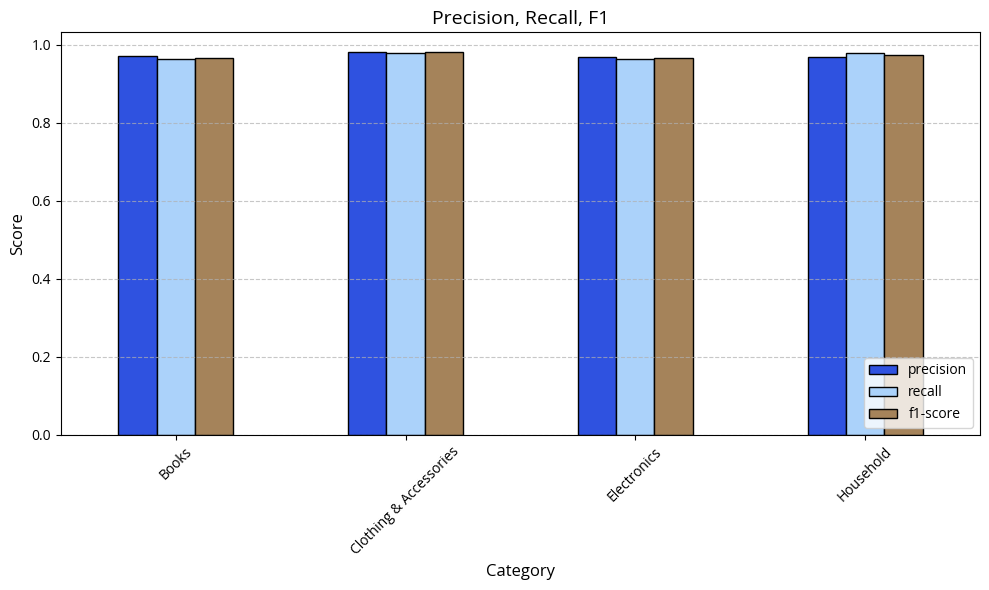

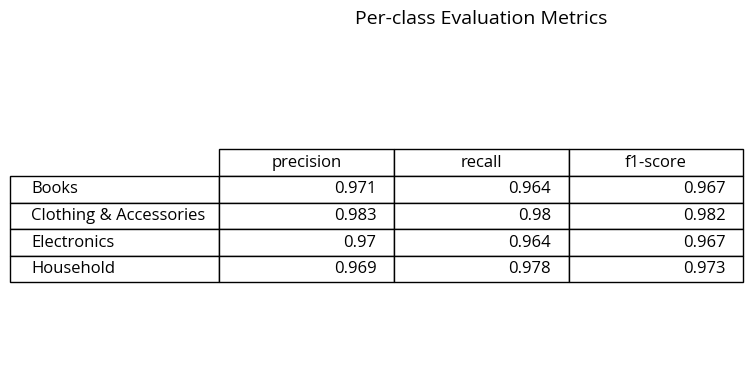

In [3]:
#SVM - TF-IDF
target_names = sorted(list(y_train.unique()))
svm_model = train_SVM(X_train, y_train, X_test, y_test, target_names)



RANDOM FOREST

--- RF Model Input Data Summary ---
X_train Shape (samples, features): (40340, 5000)
X_train Data Type: float64
y_train Shape (labels): (40340,)
y_train Data Type: object
Feature Vector Length (input_dim): 5000
Matrix Format: <class 'scipy.sparse._csr.csr_matrix'>
------------------------------
First sample (first 10 TF-IDF feature values):
Prvá vzorka (prvých 10 TF-IDF hodnôt):
[0.         0.         0.         0.         0.         0.
 0.04444515 0.         0.         0.        ]
------------------------------
                        precision    recall  f1-score   support

                 Books     0.9732    0.9683    0.9707      2364
Clothing & Accessories     0.9803    0.9740    0.9771      1734
           Electronics     0.9825    0.9515    0.9668      2124
             Household     0.9572    0.9795    0.9683      3863

              accuracy                         0.9701     10085
             macro avg     0.9733    0.9683    0.9707     10085
          weight

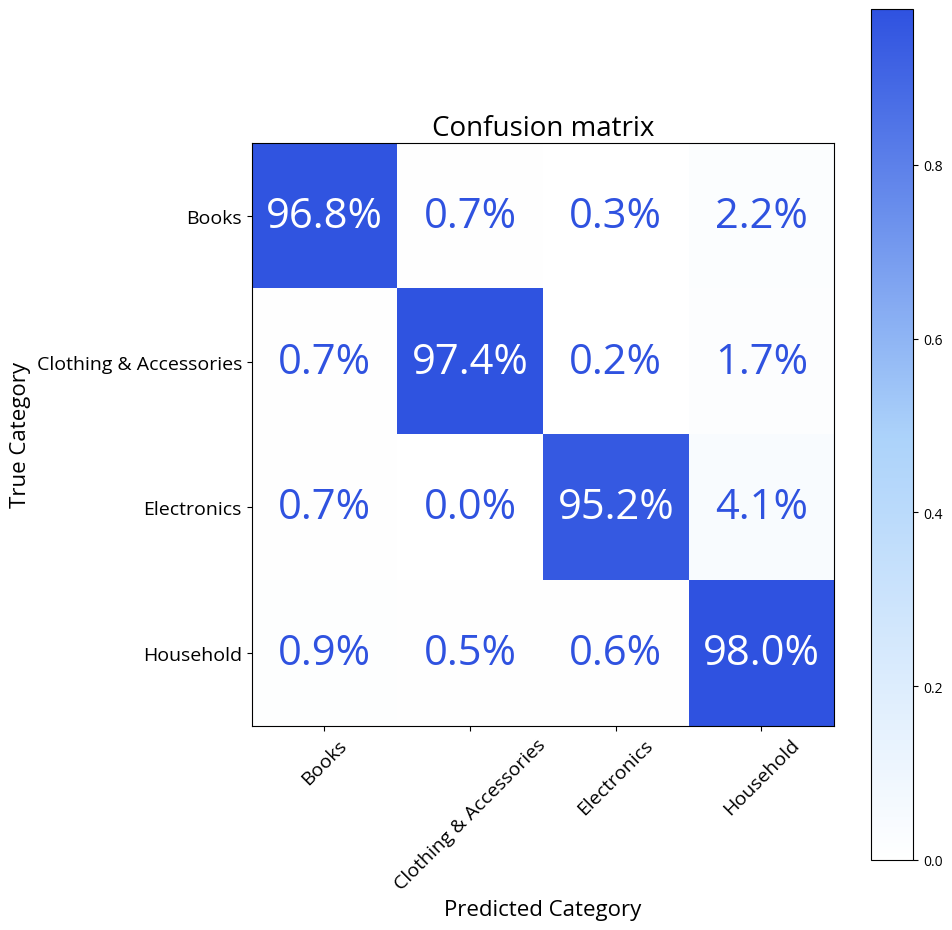

<Figure size 640x480 with 0 Axes>

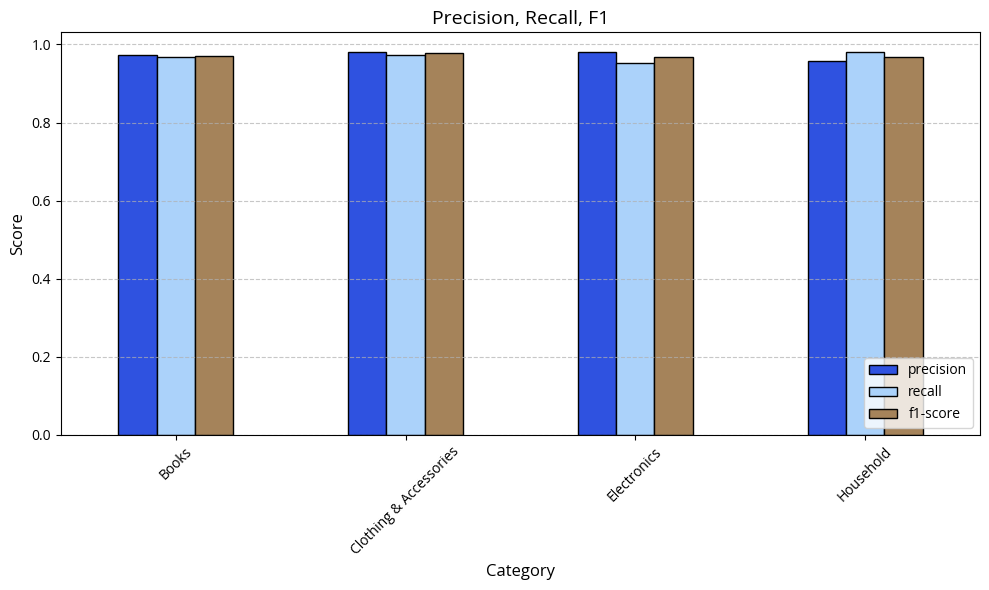

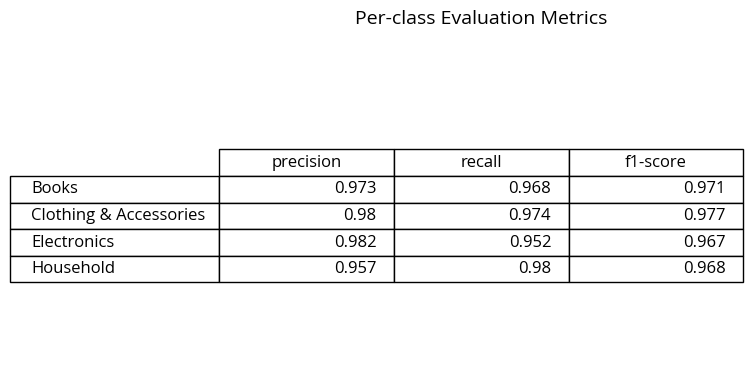

In [4]:
#RANDOM FOREST - TF-IDF
rf_model = train_random_forest(X_train, y_train, X_test, y_test, target_names)

In [5]:
import os
hf_token = os.getenv("HF_TOKEN")

import re

from sklearn.model_selection import train_test_split
import gensim.downloader    
from nltk.tokenize import word_tokenize
import nltk   
nltk.download('punkt', quiet=True)

from src.LM.embeddings.embedder_preprocess import clean_text
from src.LM.embeddings.embedder_preprocess import load_word2vec_model
from src.LM.embeddings.embedder_preprocess import text_to_vector
from src.LM.embeddings.embedder_preprocess import prepare_data_word2vec

In [6]:
#Word2Vec model

X_train_vec, X_test_vec, y_train, y_test, w2v_model = prepare_data_word2vec(df)


print("Model loaded. Vector size:", w2v_model.vector_size) 
print(df["Category"].value_counts(normalize=True))

Loading pretrained Word2Vec model from gensim…
Model loaded
Model loaded. Vector size: 300
Category
Household                 0.383004
Books                     0.234408
Electronics               0.210630
Clothing & Accessories    0.171958
Name: proportion, dtype: float64



SUPPORT VECTOR MACHINE (SVM)

--- SVM Model Input Data Summary ---
X_train Shape (samples, features): (40340, 5000)
X_train Data Type: float64
y_train Shape (labels): (40340,)
y_train Data Type: object
Feature Vector Length (input_dim): 5000
Matrix Format: <class 'scipy.sparse._csr.csr_matrix'>
------------------------------
First sample (first 10 TF-IDF feature values):
[0.         0.         0.         0.         0.         0.
 0.04444515 0.         0.         0.        ]
------------------------------

--- SVM CLASSIFICATION REPORT ---
                        precision    recall  f1-score   support

                 Books     0.9706    0.9636    0.9671      2364
Clothing & Accessories     0.9827    0.9804    0.9815      1734
           Electronics     0.9697    0.9637    0.9667      2124
             Household     0.9692    0.9777    0.9735      3863

              accuracy                         0.9719     10085
             macro avg     0.9730    0.9714    0.9722     10085
    

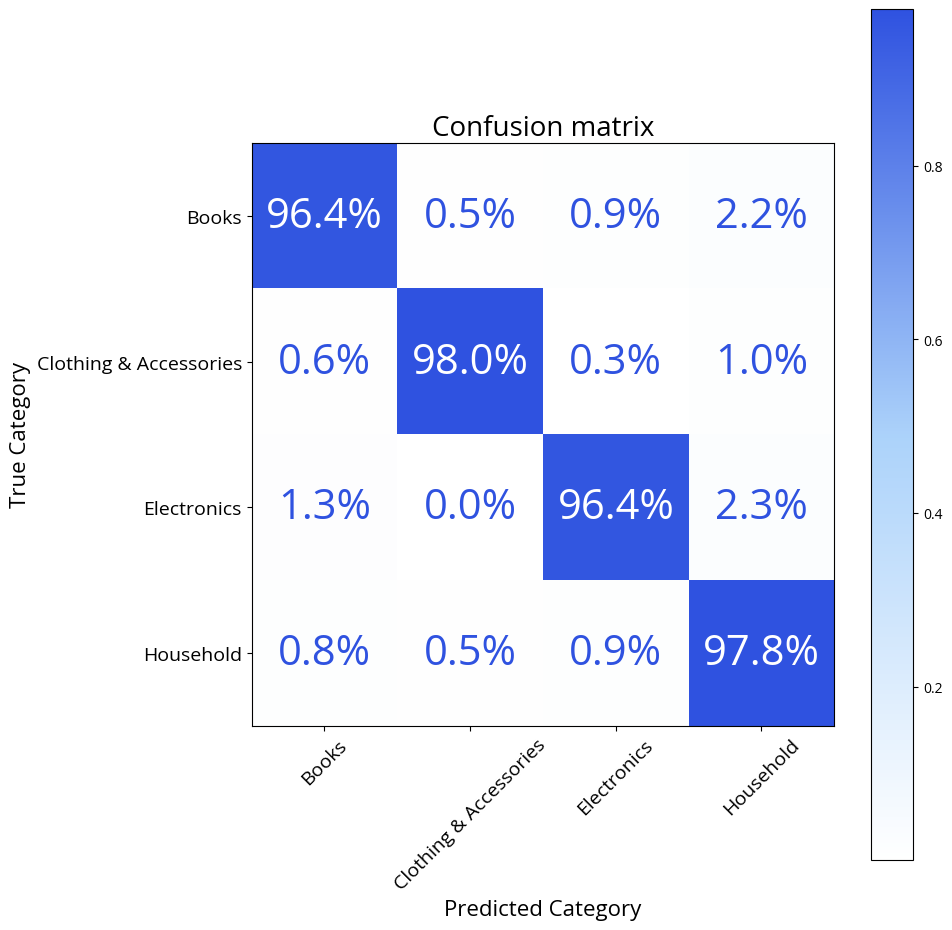

<Figure size 640x480 with 0 Axes>

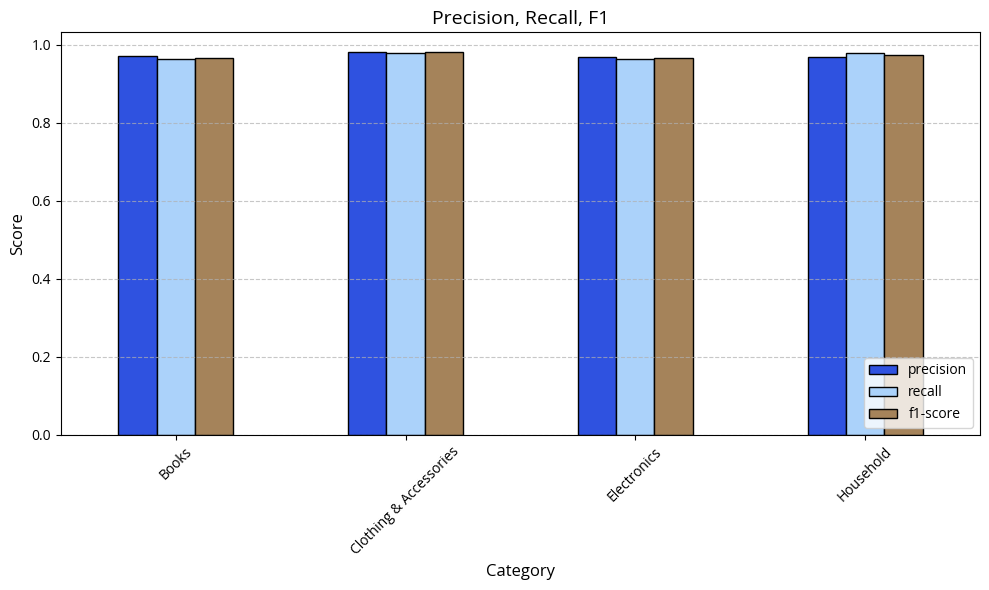

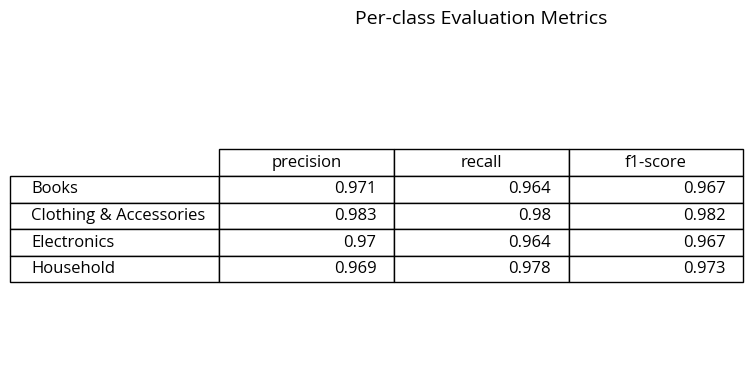

In [7]:
#SVM - Word2Vec

svm_model = train_SVM(X_train, y_train, X_test, y_test, target_names)


RANDOM FOREST

--- RF Model Input Data Summary ---
X_train Shape (samples, features): (40340, 5000)
X_train Data Type: float64
y_train Shape (labels): (40340,)
y_train Data Type: object
Feature Vector Length (input_dim): 5000
Matrix Format: <class 'scipy.sparse._csr.csr_matrix'>
------------------------------
First sample (first 10 TF-IDF feature values):
Prvá vzorka (prvých 10 TF-IDF hodnôt):
[0.         0.         0.         0.         0.         0.
 0.04444515 0.         0.         0.        ]
------------------------------
                        precision    recall  f1-score   support

                 Books     0.9732    0.9683    0.9707      2364
Clothing & Accessories     0.9803    0.9740    0.9771      1734
           Electronics     0.9825    0.9515    0.9668      2124
             Household     0.9572    0.9795    0.9683      3863

              accuracy                         0.9701     10085
             macro avg     0.9733    0.9683    0.9707     10085
          weight

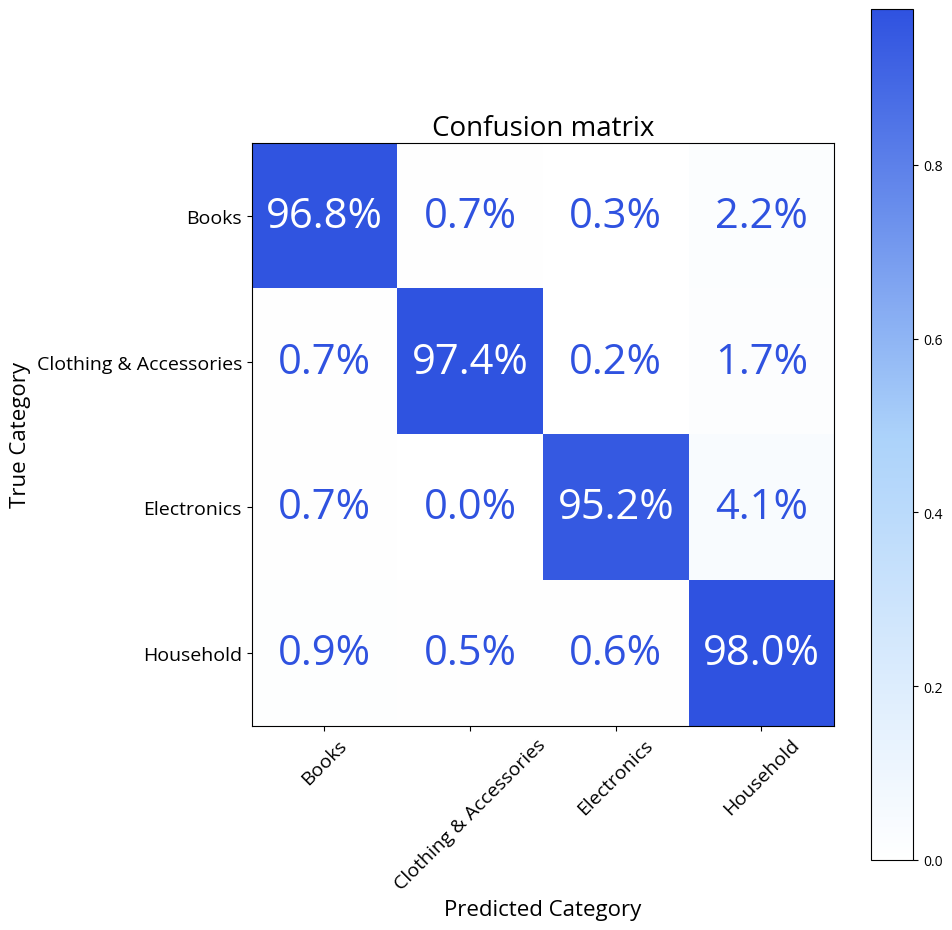

<Figure size 640x480 with 0 Axes>

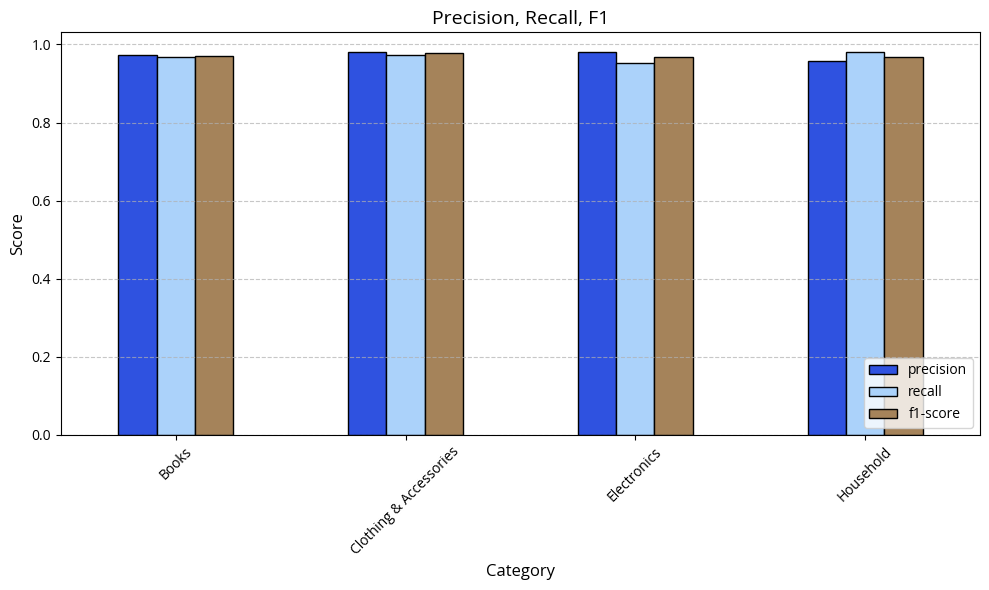

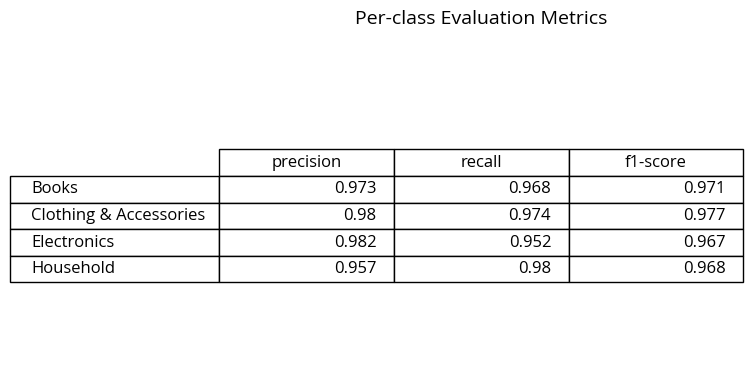

In [8]:
#RANDOM FOREST - Word2Vec

rf_model = train_random_forest(X_train, y_train, X_test, y_test, target_names)

In [9]:
#MiniLM model
from transformers import AutoTokenizer, AutoModel
import torch

from src.LM.embeddings.embedder_preprocess import load_minilm_embedder, prepare_data_minilm

# Load your dataset
df = load_data("/home/xkubanova_126831/bakalarka/e_com_dataset/data/ecommerceDataset.csv")


print(df["Category"].value_counts(normalize=True))

# MiniLM embedder
device = "cuda" if torch.cuda.is_available() else "cpu"
print('using devide:', device)
tokenizer, minilm_model = load_minilm_embedder("sentence-transformers/all-MiniLM-L6-v2", device=device)

minilm_model.eval()  


X_train_vec, X_test_vec, y_train, y_test = prepare_data_minilm(df, tokenizer, minilm_model, device=device, batch_size = 32)

print("Embeddings created. Shape:", X_train_vec.shape)
print("Categories:\n", y_train.value_counts(normalize=True))

target_names = sorted(list(y_train.unique()))

Dataset shape: (50425, 2)

Categories samples:

Books:
  Inner Engineering: A Yogi's Guide to Joy About the Author Sadhguru Jaggi VasudevSADHGURU is a yogi, mystic, and visionary who established the Isha Foundation, a nonprofit dedicated to the cultivation of human potential. He belongs to no particular tradition, and his scientific methods for self-transformation have universal appeal. Sadhguru has been an in?uential voice at global forums including th...

Clothing & Accessories:
  Woopower 36M Pink for 024M Baby Trouser Top Sets3Pcs Boy Girl Hooded Topsstriped Pantshairband Outfits36Mpink Size name36m colourpink description100 brand new and type children setgender unisexfor season autumn springcoloroptional pink greensize table 7080 90 100cminchsize tops length bust pants length age70 32 1260 46 1811 37 1457 36m80 34 1339 48 1890 39 1535 612m90 36 1417 52 2047 41 1614 1218m...

Electronics:
  Dell 19.5V-3.34AMP 65W Laptop Adapter (Without power Cord) Design Features of Dell Laptop - 

Encoding batches: 100%|██████████| 316/316 [00:02<00:00, 115.65it/s]

Embeddings created. Shape: (40340, 384)
Categories:
 Category
Household                 0.382995
Books                     0.234408
Electronics               0.210635
Clothing & Accessories    0.171963
Name: proportion, dtype: float64



SUPPORT VECTOR MACHINE (SVM)

--- SVM Model Input Data Summary ---
X_train Shape (samples, features): (40340, 384)
X_train Data Type: float32
y_train Shape (labels): (40340,)
y_train Data Type: object
Feature Vector Length (input_dim): 384
Matrix Format: <class 'numpy.ndarray'>
------------------------------
First sample (first 10 embedding values):
[ 0.05055703 -0.1124899  -0.19634616  0.2276026  -0.15286484  0.09453233
 -0.04444649  0.00246277  0.0193432  -0.13600698]
------------------------------

--- SVM CLASSIFICATION REPORT ---
                        precision    recall  f1-score   support

                 Books     0.9588    0.9450    0.9519      2364
Clothing & Accessories     0.9618    0.9717    0.9667      1734
           Electronics     0.9350    0.9204    0.9276      2124
             Household     0.9410    0.9529    0.9469      3863

              accuracy                         0.9474     10085
             macro avg     0.9491    0.9475    0.9483     10085
        

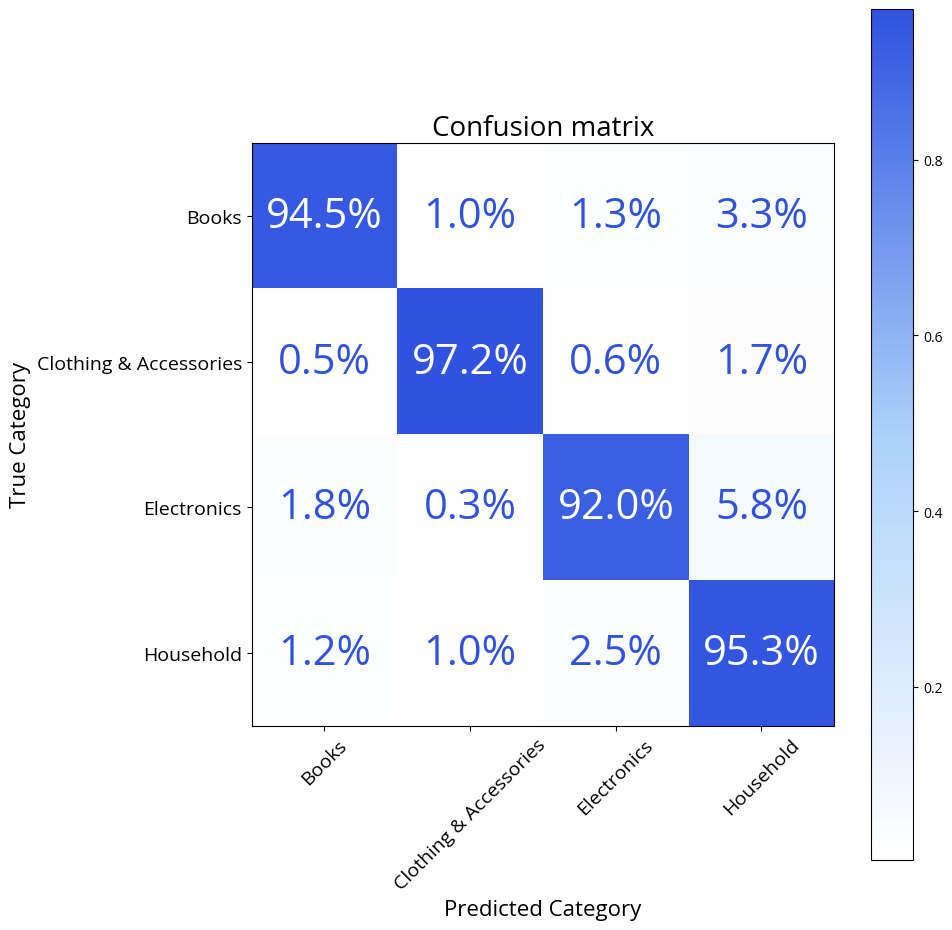

<Figure size 640x480 with 0 Axes>

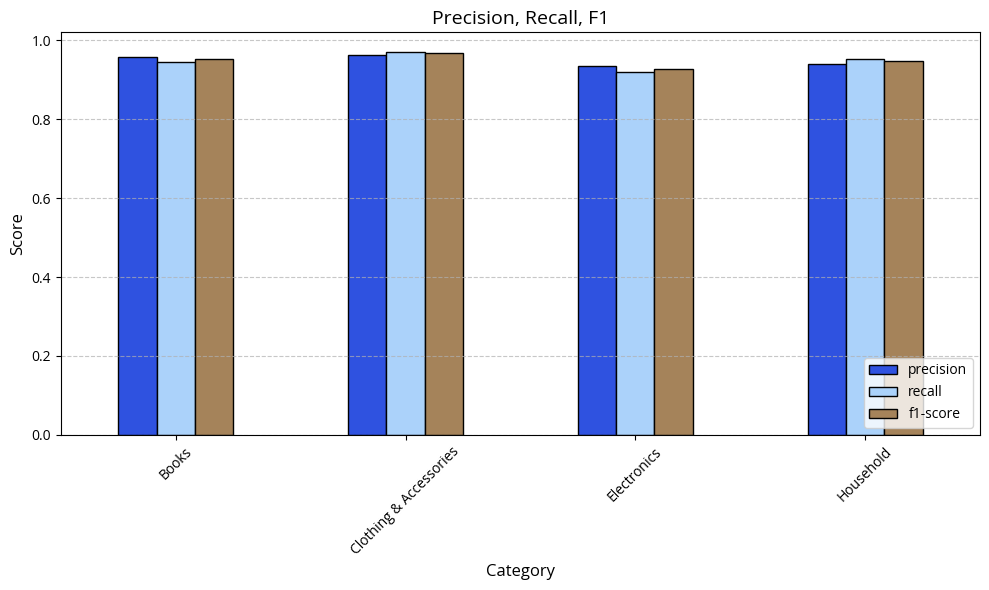

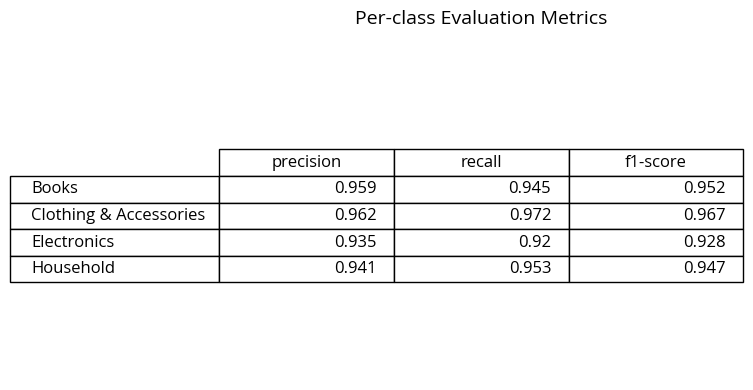

In [10]:
#SVM - MiniLM

svm_model = train_SVM(X_train_vec, y_train, X_test_vec, y_test, target_names)


RANDOM FOREST

--- RF Model Input Data Summary ---
X_train Shape (samples, features): (40340, 384)
X_train Data Type: float32
y_train Shape (labels): (40340,)
y_train Data Type: object
Feature Vector Length (input_dim): 384
Matrix Format: <class 'numpy.ndarray'>
------------------------------
First sample (first 10 embedding values):
Prvá vzorka (prvých 10 TF-IDF hodnôt):
[ 0.05055703 -0.1124899  -0.19634616  0.2276026  -0.15286484  0.09453233
 -0.04444649  0.00246277  0.0193432  -0.13600698]
------------------------------
                        precision    recall  f1-score   support

                 Books     0.9797    0.9594    0.9694      2364
Clothing & Accessories     0.9823    0.9608    0.9714      1734
           Electronics     0.9731    0.9543    0.9636      2124
             Household     0.9521    0.9837    0.9677      3863

              accuracy                         0.9679     10085
             macro avg     0.9718    0.9645    0.9680     10085
          weighted a

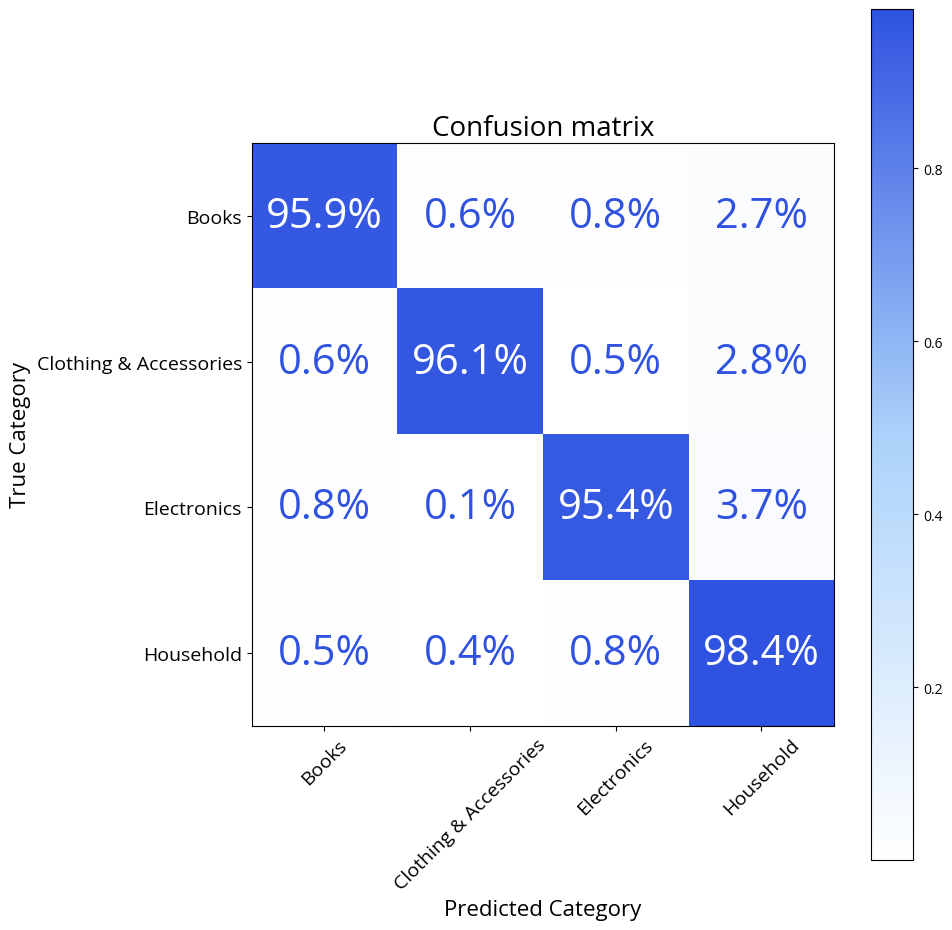

<Figure size 640x480 with 0 Axes>

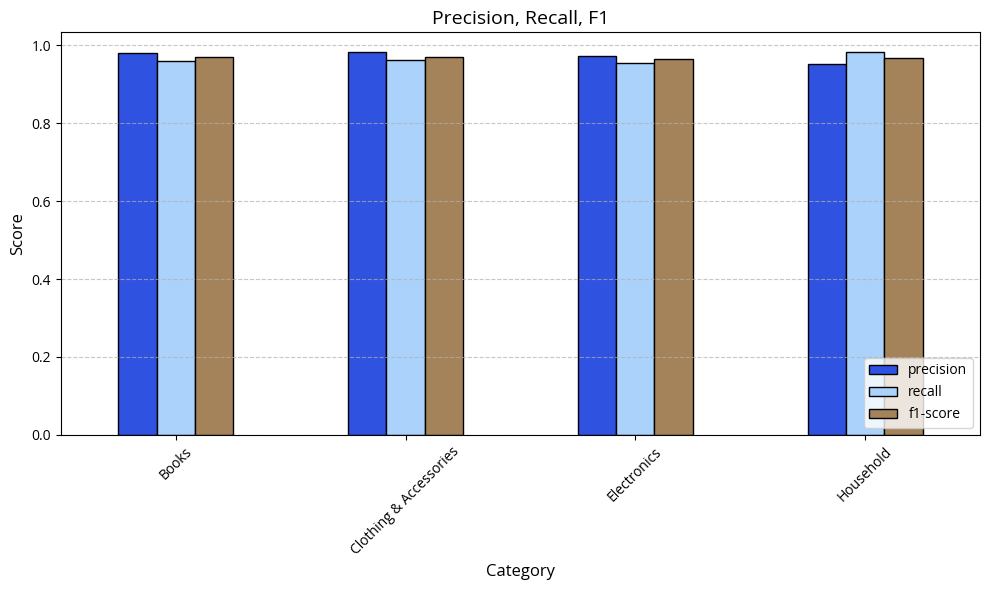

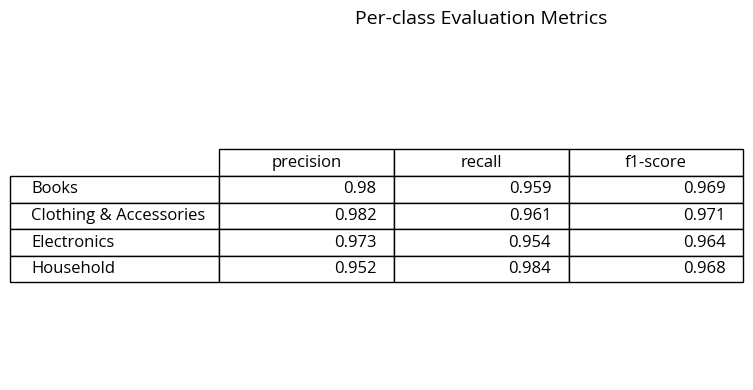

In [11]:
#RANDOM FOREST - MiniLM

rf_model = train_random_forest(X_train_vec, y_train, X_test_vec, y_test, target_names)